# Laboratorio 4: Análisis de Datos GeoEspaciales

CC3084 – Data Science

Iris Ayala - Anggie Quezada - Jonathan Diaz

Análisis de la proliferación de cianobacteria en los lagos de Atitlán y Amatitlán usando imágenes Sentinel-2.

## Librerías

In [60]:
import os
import time
import openeo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta
from dotenv import load_dotenv
from sentinelhub import SHConfig, SentinelHubRequest, SentinelHubSession, DataCollection, MimeType, CRS, BBox, bbox_to_dimensions

## 1. Conexión con la API de Sentinel-2

In [61]:
connection = openeo.connect(
    "https://openeo.dataspace.copernicus.eu"
).authenticate_oidc()

Authenticated using refresh token.


In [62]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## 2. Obtención de los datos raster

### Coordenadas de los lagos

In [63]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}

lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799
}

### Fechas oficiales por lago

In [64]:
fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
    "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28", "2026-07-22"
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
    "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28", "2026-06-19"
]

### Configuración de Sentinel Hub

In [65]:
load_dotenv()

config = SHConfig()
config.sh_client_id = os.environ["SH_CLIENT_ID"]
config.sh_client_secret = os.environ["SH_CLIENT_SECRET"]
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

coleccion_s2 = DataCollection.SENTINEL2_L2A.define_from("coleccion_s2", service_url=config.sh_base_url)

### Descarga de bandas

Se descargan únicamente las bandas B03, B04 y B08, necesarias para calcular NDVI y NDWI.

In [66]:
evalscript_bandas = """
//VERSION=3
function setup() {
  return {
    input: ["B03", "B04", "B08"],
    output: { bands: 3, sampleType: "UINT16" }
  };
}
function evaluatePixel(s) {
  return [s.B03, s.B04, s.B08];
}
"""

In [67]:
def descargar_bandas(bbox_dict, fecha, intentos=3):
    bbox = BBox(bbox=[bbox_dict["west"], bbox_dict["south"], bbox_dict["east"], bbox_dict["north"]], crs=CRS.WGS84)
    tamano = bbox_to_dimensions(bbox, resolution=20)
    solicitud = SentinelHubRequest(
        evalscript=evalscript_bandas,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=coleccion_s2,
                time_interval=(fecha, fecha)
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=tamano,
        config=config
    )
    for intento in range(intentos):
        try:
            return solicitud.get_data()[0]
        except Exception:
            if intento == intentos - 1:
                raise
            SentinelHubSession.clear_cache()
            time.sleep(5)

In [68]:
bandas_atitlan = {fecha: descargar_bandas(lago_atitlan, fecha) for fecha in fechas_atitlan}
bandas_amatitlan = {fecha: descargar_bandas(lago_amatitlan, fecha) for fecha in fechas_amatitlan}

### Verificación de una imagen descargada

In [69]:
print("Dimensiones:", bandas_atitlan[fechas_atitlan[0]].shape)

Dimensiones: (875, 1365, 3)


**Interpretación**

Las dimensiones obtenidas corresponden al recorte del área de cada lago a una resolución de 20 metros por pixel, con 3 bandas (B03, B04, B08). El tamaño coincide con lo esperado para el tamaño geográfico de cada lago.

## 3. Índice de cianobacteria, NDVI y NDWI

### 3.1 Script de detección de cianobacteria

Se usa el script "Cyanobacteria Chlorophyll-a NDCI L1C" de https://custom-scripts.sentinel-hub.com. El script original devuelve un color RGB para visualizar la floración. Se adapta la salida para que devuelva el valor numérico de clorofila-a (`chl`) en lugar del color, manteniendo la misma lógica de detección de agua y el mismo modelo NDCI, ya que el análisis temporal y de correlación (Ejercicio 4) necesita valores numéricos.

Valores de salida:
- `0`: pixel que no es agua.
- `-1`: agua con floración superficial detectada (índice de vegetación flotante alto).
- cualquier otro valor: estimado de clorofila-a (proxy de cianobacteria).

In [70]:
evalscript_cianobacteria = """
//VERSION=3
function setup() {
  return {
    input: ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"],
    output: { bands: 1, sampleType: "FLOAT32" }
  };
}

var MNDWI_threshold = 0.42;
var NDWI_threshold = 0.4;
var filter_UABS = true;

function wbi(r, g, b, nir, swir1, swir2) {
  let ws = 0;
  try {
    var ndvi = (nir - r) / (nir + r);
    var mndwi = (g - swir1) / (g + swir1);
    var ndwi = (g - nir) / (g + nir);
    var ndwi_leaves = (nir - swir1) / (nir + swir1);
    var aweish = b + 2.5 * g - 1.5 * (nir + swir1) - 0.25 * swir2;
    var aweinsh = 4 * (g - swir1) - (0.25 * nir + 2.75 * swir1);
    var dbsi = ((swir1 - g) / (swir1 + g)) - ndvi;
    if (mndwi > MNDWI_threshold || ndwi > NDWI_threshold || aweinsh > 0.1879 || aweish > 0.1112 || ndvi < -0.2 || ndwi_leaves > 1) {
      ws = 1;
    }
    if (filter_UABS && ws == 1) {
      if (aweinsh <= -0.03 || dbsi > 0) { ws = 0; }
    }
  } catch (err) { ws = 0; }
  return ws;
}

function FAI(a, b, c) {
  return (b - a - (c - a) * (783 - 665) / (865 - 665));
}

function NDCI(a, b) {
  return (b - a) / (b + a);
}

function evaluatePixel(s) {
  let water = wbi(s.B04, s.B03, s.B02, s.B08, s.B11, s.B12);
  if (water == 0) { return [0]; }

  let FAIv = FAI(s.B04, s.B07, s.B8A);
  if (FAIv > 0.08) { return [-1]; }

  let NDCIv = NDCI(s.B04, s.B05);
  let chl = 826.57 * Math.pow(NDCIv, 3) - 176.43 * Math.pow(NDCIv, 2) + 19 * NDCIv + 4.071;
  return [chl];
}
"""

### 3.2 Función para obtener el índice de cianobacteria

In [71]:
def obtener_indice_cianobacteria(bbox_dict, fecha, intentos=3):
    bbox = BBox(bbox=[bbox_dict["west"], bbox_dict["south"], bbox_dict["east"], bbox_dict["north"]], crs=CRS.WGS84)
    tamano = bbox_to_dimensions(bbox, resolution=20)
    solicitud = SentinelHubRequest(
        evalscript=evalscript_cianobacteria,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=coleccion_s2,
                time_interval=(fecha, fecha)
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=tamano,
        config=config
    )
    for intento in range(intentos):
        try:
            return solicitud.get_data()[0]
        except Exception:
            if intento == intentos - 1:
                raise
            SentinelHubSession.clear_cache()
            time.sleep(5)

### Cálculo de NDVI y NDWI a partir de las bandas descargadas

In [72]:
def calcular_ndvi_ndwi(bandas_arr):
    green = bandas_arr[:, :, 0].astype(np.float32) / 10000
    red = bandas_arr[:, :, 1].astype(np.float32) / 10000
    nir = bandas_arr[:, :, 2].astype(np.float32) / 10000
    with np.errstate(divide="ignore", invalid="ignore"):
        ndvi = np.where((nir + red) == 0, 0, (nir - red) / (nir + red))
        ndwi = np.where((green + nir) == 0, 0, (green - nir) / (green + nir))
    ndvi = np.nan_to_num(ndvi, nan=0.0)
    ndwi = np.nan_to_num(ndwi, nan=0.0)
    return ndvi, ndwi

### Cálculo para todas las fechas de cada lago

In [73]:
resultados_atitlan = {}
for fecha in fechas_atitlan:
    ndvi, ndwi = calcular_ndvi_ndwi(bandas_atitlan[fecha])
    cianobacteria = obtener_indice_cianobacteria(lago_atitlan, fecha)
    resultados_atitlan[fecha] = {"ndvi": ndvi, "ndwi": ndwi, "cianobacteria": cianobacteria}

In [74]:
resultados_amatitlan = {}
for fecha in fechas_amatitlan:
    ndvi, ndwi = calcular_ndvi_ndwi(bandas_amatitlan[fecha])
    cianobacteria = obtener_indice_cianobacteria(lago_amatitlan, fecha)
    resultados_amatitlan[fecha] = {"ndvi": ndvi, "ndwi": ndwi, "cianobacteria": cianobacteria}

### Visualización del índice de cianobacteria

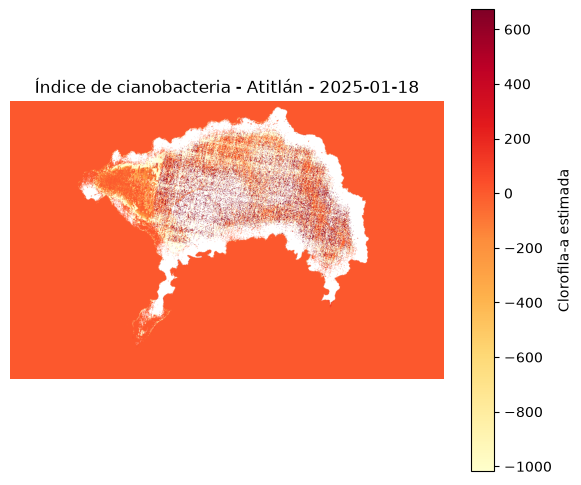

In [75]:
fecha_ejemplo_atitlan = fechas_atitlan[0]
plt.figure(figsize=(7, 6))
plt.imshow(resultados_atitlan[fecha_ejemplo_atitlan]["cianobacteria"], cmap="YlOrRd")
plt.title(f"Índice de cianobacteria - Atitlán - {fecha_ejemplo_atitlan}")
plt.colorbar(label="Clorofila-a estimada")
plt.axis("off")
plt.show()

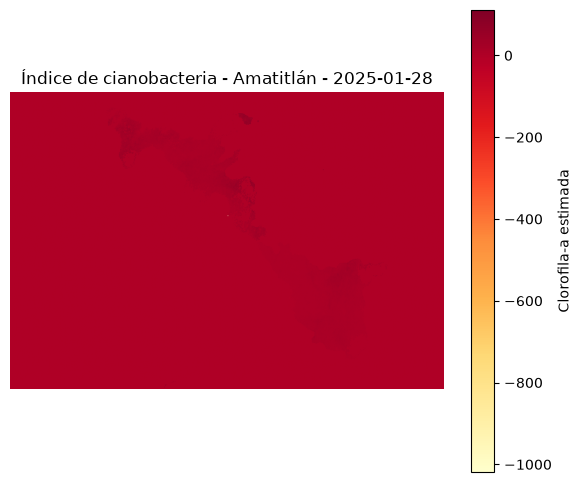

In [76]:
fecha_ejemplo_amatitlan = fechas_amatitlan[0]
plt.figure(figsize=(7, 6))
plt.imshow(resultados_amatitlan[fecha_ejemplo_amatitlan]["cianobacteria"], cmap="YlOrRd")
plt.title(f"Índice de cianobacteria - Amatitlán - {fecha_ejemplo_amatitlan}")
plt.colorbar(label="Clorofila-a estimada")
plt.axis("off")
plt.show()

## 4. Análisis temporal

### 4.1 Índice promedio de cianobacteria por lago y por fecha

In [77]:
def promedio_cianobacteria(arr):
    valido = arr[arr > 0]
    if valido.size == 0:
        return np.nan
    return np.nanmean(valido)

In [78]:
promedio_atitlan = {fecha: promedio_cianobacteria(resultados_atitlan[fecha]["cianobacteria"]) for fecha in fechas_atitlan}

df_atitlan = pd.DataFrame(list(promedio_atitlan.items()), columns=["fecha", "cianobacteria_promedio"])
df_atitlan["fecha"] = pd.to_datetime(df_atitlan["fecha"])
df_atitlan = df_atitlan.sort_values("fecha").reset_index(drop=True)
df_atitlan

,fecha,cianobacteria_promedio
0,2025-01-18,381.082611
1,2025-04-13,3.229907
2,2025-05-13,3.622993
3,2025-07-17,4.240981
4,2025-11-21,7.468000
5,2025-12-29,4.948601
6,2026-02-12,6.826056
7,2026-03-24,3.672394
8,2026-04-13,3.552755
9,2026-04-28,3.138311


In [79]:
promedio_amatitlan = {fecha: promedio_cianobacteria(resultados_amatitlan[fecha]["cianobacteria"]) for fecha in fechas_amatitlan}

df_amatitlan = pd.DataFrame(list(promedio_amatitlan.items()), columns=["fecha", "cianobacteria_promedio"])
df_amatitlan["fecha"] = pd.to_datetime(df_amatitlan["fecha"])
df_amatitlan = df_amatitlan.sort_values("fecha").reset_index(drop=True)
df_amatitlan

,fecha,cianobacteria_promedio
0,2025-01-28,14.914059
1,2025-04-15,10.446157
2,2025-04-28,13.599401
3,2025-11-24,13.132152
4,2026-01-08,23.132414
5,2026-02-02,6.898146
6,2026-02-07,8.121027
7,2026-03-29,17.208698
8,2026-04-13,16.572437
9,2026-04-28,24.688444


### 4.2 Evolución temporal

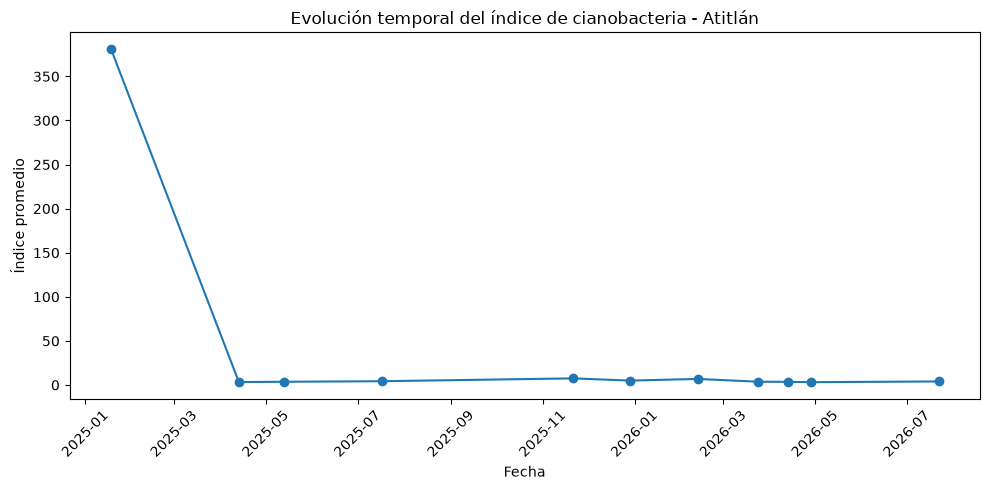

In [80]:
plt.figure(figsize=(10, 5))
plt.plot(df_atitlan["fecha"], df_atitlan["cianobacteria_promedio"], marker="o")
plt.title("Evolución temporal del índice de cianobacteria - Atitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

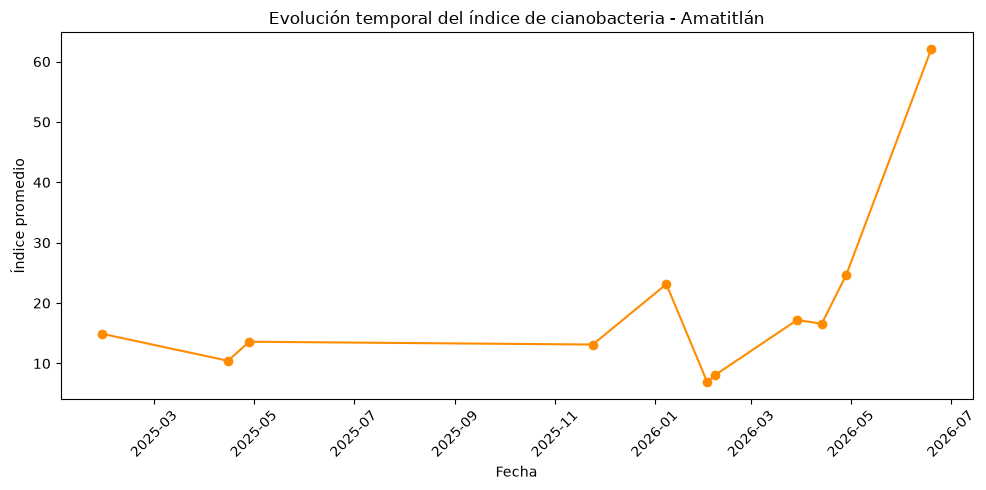

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(df_amatitlan["fecha"], df_amatitlan["cianobacteria_promedio"], marker="o", color="darkorange")
plt.title("Evolución temporal del índice de cianobacteria - Amatitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Picos de floración y fechas críticas

In [82]:
pico_atitlan = df_atitlan.loc[df_atitlan["cianobacteria_promedio"].idxmax()]
pico_amatitlan = df_amatitlan.loc[df_amatitlan["cianobacteria_promedio"].idxmax()]

print("Pico Atitlán:", pico_atitlan["fecha"].date(), "-", round(pico_atitlan["cianobacteria_promedio"], 4))
print("Pico Amatitlán:", pico_amatitlan["fecha"].date(), "-", round(pico_amatitlan["cianobacteria_promedio"], 4))

Pico Atitlán: 2025-01-18 - 381.0826
Pico Amatitlán: 2026-06-19 - 62.0872


## 5. Ejercicio 1: Preparación de Datos para Machine Learning

### 1.1 Construcción del conjunto de datos etiquetado para Machine Learning

Se construye un dataset donde cada fila representa un píxel con sus características espectrales, ubicación geográfica, fecha y lago de origen.

In [83]:
def crear_dataset_ml(resultados_lago, fechas, bbox_dict, nombre_lago):
    """
    Convierte las imágenes raster en un dataset tabular para ML.
    Cada fila = un píxel con características y etiqueta (cianobacteria).
    """
    datos = []
    
    for fecha in fechas:
        if fecha not in resultados_lago:
            continue
            
        ndvi = resultados_lago[fecha]["ndvi"]
        ndwi = resultados_lago[fecha]["ndwi"]
        cianobacteria = resultados_lago[fecha]["cianobacteria"]
        
        # Obtener coordenadas del píxel
        altura, ancho = ndvi.shape
        
        # Calcular paso en grados
        lat_paso = (bbox_dict["north"] - bbox_dict["south"]) / altura
        lon_paso = (bbox_dict["east"] - bbox_dict["west"]) / ancho
        
        # Recorrer cada píxel
        for i in range(altura):
            for j in range(ancho):
                lat = bbox_dict["north"] - (i + 0.5) * lat_paso
                lon = bbox_dict["west"] + (j + 0.5) * lon_paso
                
                datos.append({
                    "fecha": fecha,
                    "lago": nombre_lago,
                    "latitud": lat,
                    "longitud": lon,
                    "ndvi": ndvi[i, j],
                    "ndwi": ndwi[i, j],
                    "cianobacteria": cianobacteria[i, j]
                })
    
    return pd.DataFrame(datos)

# Construir datasets para ambos lagos
print("Construyendo datasets...")
df_ml_atitlan = crear_dataset_ml(resultados_atitlan, fechas_atitlan, lago_atitlan, "Atitlán")
df_ml_amatitlan = crear_dataset_ml(resultados_amatitlan, fechas_amatitlan, lago_amatitlan, "Amatitlán")

# Combinar en un único dataset
df_ml = pd.concat([df_ml_atitlan, df_ml_amatitlan], ignore_index=True)

print(f"\nDataset total: {len(df_ml)} observaciones")
print(f"Atitlán: {len(df_ml_atitlan)} píxeles")
print(f"Amatitlán: {len(df_ml_amatitlan)} píxeles")
print(f"\nPrimeras filas:")
print(df_ml.head(10))

Construyendo datasets...

Dataset total: 16513585 observaciones
Atitlán: 13138125 píxeles
Amatitlán: 3375460 píxeles

Primeras filas:
        fecha     lago   latitud   longitud  ndvi  ndwi  cianobacteria
0  2025-01-18  Atitlán  14.75089 -91.326163   0.0   0.0            0.0
1  2025-01-18  Atitlán  14.75089 -91.325976   0.0   0.0            0.0
2  2025-01-18  Atitlán  14.75089 -91.325789   0.0   0.0            0.0
3  2025-01-18  Atitlán  14.75089 -91.325603   0.0   0.0            0.0
4  2025-01-18  Atitlán  14.75089 -91.325416   0.0   0.0            0.0
5  2025-01-18  Atitlán  14.75089 -91.325230   0.0   0.0            0.0
6  2025-01-18  Atitlán  14.75089 -91.325043   0.0   0.0            0.0
7  2025-01-18  Atitlán  14.75089 -91.324856   0.0   0.0            0.0
8  2025-01-18  Atitlán  14.75089 -91.324670   0.0   0.0            0.0
9  2025-01-18  Atitlán  14.75089 -91.324483   0.0   0.0            0.0


### 1.2 Características derivadas del dataset

Se derivan características adicionales a partir de NDVI, NDWI y la información geoespacial.

In [84]:
# Derivar características
df_ml["ndvi_ndwi_ratio"] = np.where(df_ml["ndwi"] != 0, df_ml["ndvi"] / (df_ml["ndwi"] + 1e-6), 0)
df_ml["ndvi_ndwi_sum"] = df_ml["ndvi"] + df_ml["ndwi"]
df_ml["ndvi_ndwi_diff"] = df_ml["ndvi"] - df_ml["ndwi"]

# Crear variable binaria para agua (basada en NDWI > 0.3)
df_ml["es_agua"] = (df_ml["ndwi"] > 0.3).astype(int)

# Crear variable binaria para presencia de cianobacteria (valor > 0)
df_ml["tiene_cianobacteria"] = (df_ml["cianobacteria"] > 0).astype(int)

# Convertir fecha a datetime
df_ml["fecha"] = pd.to_datetime(df_ml["fecha"])

# Extraer características temporales
df_ml["mes"] = df_ml["fecha"].dt.month
df_ml["dia"] = df_ml["fecha"].dt.day
df_ml["año"] = df_ml["fecha"].dt.year

print("Características derivadas creadas:")
print(f"Total de características: {len(df_ml.columns)}")
print(f"\nColumnas del dataset:")
print(df_ml.columns.tolist())
print(f"\nForma del dataset: {df_ml.shape}")

Características derivadas creadas:
Total de características: 15

Columnas del dataset:
['fecha', 'lago', 'latitud', 'longitud', 'ndvi', 'ndwi', 'cianobacteria', 'ndvi_ndwi_ratio', 'ndvi_ndwi_sum', 'ndvi_ndwi_diff', 'es_agua', 'tiene_cianobacteria', 'mes', 'dia', 'año']

Forma del dataset: (16513585, 15)


### 1.3 Análisis exploratorio descriptivo

Análisis descriptivo de las variables espectrales principales: NDVI, NDWI e índice de cianobacteria.

In [85]:
# Estadísticas descriptivas de variables principales
print("=" * 80)
print("ANÁLISIS DESCRIPTIVO DEL DATASET")
print("=" * 80)

print("\n1. NDVI (Índice de Vegetación de Diferencia Normalizada)")
print("-" * 60)
print(df_ml["ndvi"].describe())

print("\n2. NDWI (Índice de Agua de Diferencia Normalizada)")
print("-" * 60)
print(df_ml["ndwi"].describe())

print("\n3. Cianobacteria (Variable Respuesta)")
print("-" * 60)
print(df_ml["cianobacteria"].describe())

# Estadísticas por lago
print("\n" + "=" * 80)
print("ESTADÍSTICAS POR LAGO")
print("=" * 80)

for lago in df_ml["lago"].unique():
    df_lago = df_ml[df_ml["lago"] == lago]
    print(f"\n{lago}:")
    print(f"  - Total de píxeles: {len(df_lago)}")
    print(f"  - NDVI: μ={df_lago['ndvi'].mean():.4f}, σ={df_lago['ndvi'].std():.4f}")
    print(f"  - NDWI: μ={df_lago['ndwi'].mean():.4f}, σ={df_lago['ndwi'].std():.4f}")
    print(f"  - Cianobacteria: μ={df_lago['cianobacteria'].mean():.4f}, σ={df_lago['cianobacteria'].std():.4f}")
    print(f"  - % píxeles con agua: {df_lago['es_agua'].mean()*100:.2f}%")
    print(f"  - % píxeles con cianobacteria: {df_lago['tiene_cianobacteria'].mean()*100:.2f}%")

ANÁLISIS DESCRIPTIVO DEL DATASET

1. NDVI (Índice de Vegetación de Diferencia Normalizada)
------------------------------------------------------------
count    1.651358e+07
mean     1.800340e-02
std      1.343527e-01
min     -1.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: ndvi, dtype: float64

2. NDWI (Índice de Agua de Diferencia Normalizada)
------------------------------------------------------------
count    1.651358e+07
mean    -1.772424e-02
std      1.336103e-01
min     -1.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: ndwi, dtype: float64

3. Cianobacteria (Variable Respuesta)
------------------------------------------------------------
count    1.634832e+07
mean    -2.323110e+00
std      6.977114e+01
min     -1.017929e+03
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.732110e+02
Name: cianobacteria, dtype: float64

ESTADÍSTICAS POR

### 1.4 Análisis de distribuciones por lago y por fecha

Análisis del número de observaciones disponibles por lago y por fecha.

Distribución por lago:
lago
Amatitlán     3375460
Atitlán      13138125
Name: count, dtype: int64

VISUALIZACIÓN: Observaciones por lago y por fecha


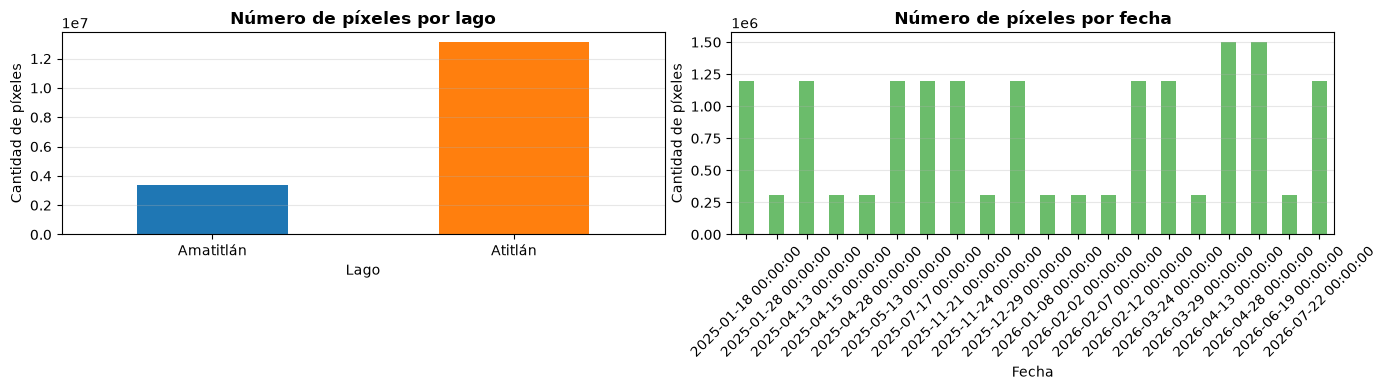

In [86]:
# Distribución de observaciones por lago
print("Distribución por lago:")
dist_lago = df_ml["lago"].value_counts().sort_index()
print(dist_lago)

print("\n" + "="*60)
print("VISUALIZACIÓN: Observaciones por lago y por fecha")
print("="*60)

# Visualización: observaciones por lago
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1: Observaciones por lago
dist_lago.plot(kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e"])
axes[0].set_title("Número de píxeles por lago", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Lago")
axes[0].set_ylabel("Cantidad de píxeles")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis="y", alpha=0.3)

# Gráfico 2: Observaciones por fecha
dist_fecha = df_ml["fecha"].value_counts().sort_index()
dist_fecha.plot(kind="bar", ax=axes[1], color="#2ca02c", alpha=0.7)
axes[1].set_title("Número de píxeles por fecha", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Cantidad de píxeles")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 1.5 Análisis exploratorio de variables con histogramas y estadísticas

Histogramas y distribuciones de NDVI, NDWI y cianobacteria para identificar patrones y valores atípicos.

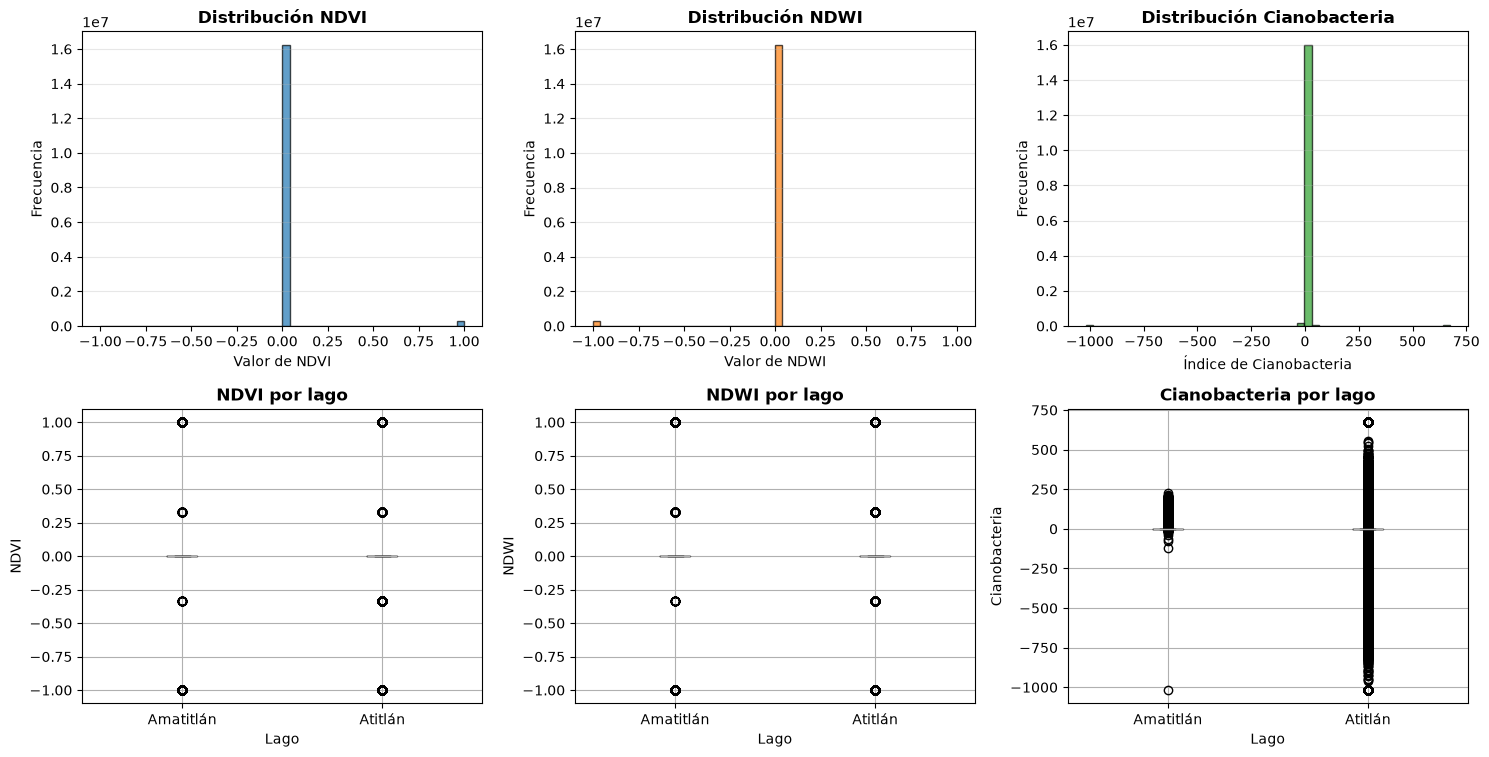


Matriz de correlación (variables principales):
                  ndvi      ndwi  cianobacteria
ndvi           1.00000 -0.987840       0.004480
ndwi          -0.98784  1.000000      -0.004431
cianobacteria  0.00448 -0.004431       1.000000


In [87]:
# Histogramas de las variables principales
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# NDVI
axes[0, 0].hist(df_ml["ndvi"], bins=50, color="#1f77b4", alpha=0.7, edgecolor="black")
axes[0, 0].set_title("Distribución NDVI", fontweight="bold")
axes[0, 0].set_xlabel("Valor de NDVI")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].grid(axis="y", alpha=0.3)

# NDWI
axes[0, 1].hist(df_ml["ndwi"], bins=50, color="#ff7f0e", alpha=0.7, edgecolor="black")
axes[0, 1].set_title("Distribución NDWI", fontweight="bold")
axes[0, 1].set_xlabel("Valor de NDWI")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].grid(axis="y", alpha=0.3)

# Cianobacteria
axes[0, 2].hist(df_ml["cianobacteria"], bins=50, color="#2ca02c", alpha=0.7, edgecolor="black")
axes[0, 2].set_title("Distribución Cianobacteria", fontweight="bold")
axes[0, 2].set_xlabel("Índice de Cianobacteria")
axes[0, 2].set_ylabel("Frecuencia")
axes[0, 2].grid(axis="y", alpha=0.3)

# Box plots por lago
df_ml.boxplot(column="ndvi", by="lago", ax=axes[1, 0])
axes[1, 0].set_title("NDVI por lago", fontweight="bold")
axes[1, 0].set_xlabel("Lago")
axes[1, 0].set_ylabel("NDVI")

df_ml.boxplot(column="ndwi", by="lago", ax=axes[1, 1])
axes[1, 1].set_title("NDWI por lago", fontweight="bold")
axes[1, 1].set_xlabel("Lago")
axes[1, 1].set_ylabel("NDWI")

df_ml.boxplot(column="cianobacteria", by="lago", ax=axes[1, 2])
axes[1, 2].set_title("Cianobacteria por lago", fontweight="bold")
axes[1, 2].set_xlabel("Lago")
axes[1, 2].set_ylabel("Cianobacteria")

plt.tight_layout()
plt.suptitle("")  # Remover título automático
plt.show()

# Correlación entre variables
print("\nMatriz de correlación (variables principales):")
corr_vars = df_ml[["ndvi", "ndwi", "cianobacteria"]].corr()
print(corr_vars)

### 1.6 Análisis de la distribución de la variable respuesta (cianobacteria)

Análisis detallado de la distribución del índice de cianobacteria globalmente, por lago y por fecha.

ANÁLISIS DE LA VARIABLE RESPUESTA: CIANOBACTERIA

Globalmente:
  Valores > 0: 2081131 (12.60%)
  Valores = 0: 13880688 (84.06%)
  Valores = -1: 722 (0.00%)

Por lago:

  Amatitlán:
    - Píxeles con cianobacteria: 259891 (7.70%)
    - Píxeles sin detectar agua: 3114859 (92.28%)
    - Píxeles con floración superficial: 671 (0.02%)

  Atitlán:
    - Píxeles con cianobacteria: 1821240 (13.86%)
    - Píxeles sin detectar agua: 10765829 (81.94%)
    - Píxeles con floración superficial: 51 (0.00%)


Por fecha (promedio de cianobacteria para píxeles con agua):
             count        mean         std       min         max
fecha                                                           
2025-01-18   55593  381.082611  319.580811  0.014322  673.210999
2025-01-28   27816   14.914059    8.721342  1.575714  111.646606
2025-04-13  222755    3.229907    0.901058  0.000348   22.445086
2025-04-15   11756   10.446156    8.935078  2.161159   73.916359
2025-04-28   23223   13.599401   15.985321  0.4531

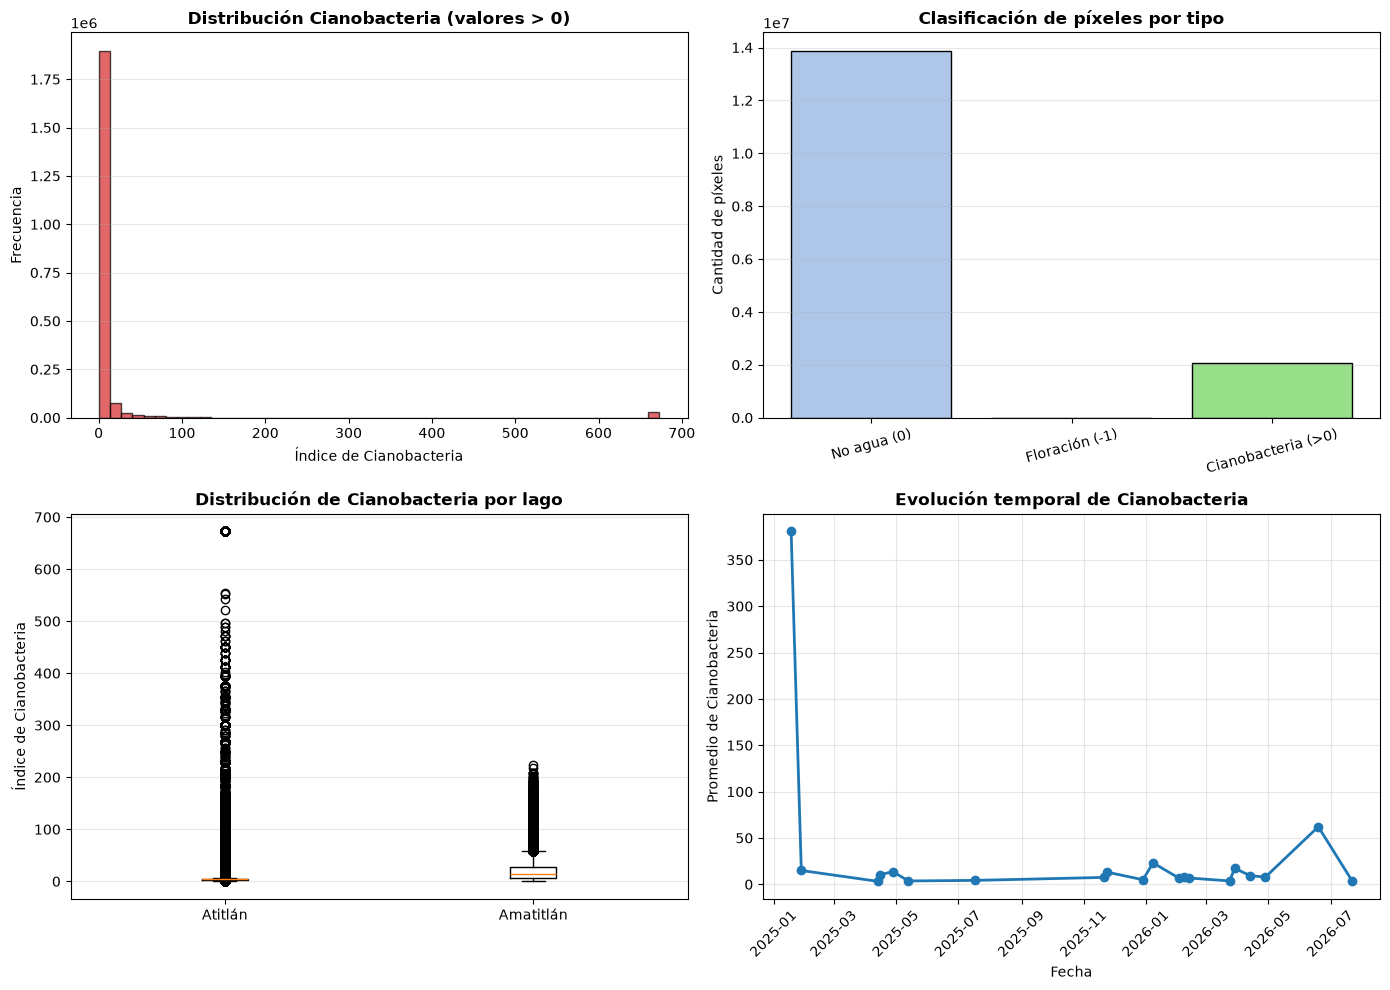

In [88]:
# Análisis de la variable respuesta: cianobacteria
print("=" * 80)
print("ANÁLISIS DE LA VARIABLE RESPUESTA: CIANOBACTERIA")
print("=" * 80)

# Estadísticas globales
print("\nGlobalmente:")
print(f"  Valores > 0: {(df_ml['cianobacteria'] > 0).sum()} ({(df_ml['cianobacteria'] > 0).mean()*100:.2f}%)")
print(f"  Valores = 0: {(df_ml['cianobacteria'] == 0).sum()} ({(df_ml['cianobacteria'] == 0).mean()*100:.2f}%)")
print(f"  Valores = -1: {(df_ml['cianobacteria'] == -1).sum()} ({(df_ml['cianobacteria'] == -1).mean()*100:.2f}%)")

# Por lago
print("\nPor lago:")
for lago in sorted(df_ml["lago"].unique()):
    df_lago = df_ml[df_ml["lago"] == lago]
    print(f"\n  {lago}:")
    print(f"    - Píxeles con cianobacteria: {(df_lago['cianobacteria'] > 0).sum()} ({(df_lago['cianobacteria'] > 0).mean()*100:.2f}%)")
    print(f"    - Píxeles sin detectar agua: {(df_lago['cianobacteria'] == 0).sum()} ({(df_lago['cianobacteria'] == 0).mean()*100:.2f}%)")
    print(f"    - Píxeles con floración superficial: {(df_lago['cianobacteria'] == -1).sum()} ({(df_lago['cianobacteria'] == -1).mean()*100:.2f}%)")

# Por fecha (solo para observaciones positivas)
print("\n\nPor fecha (promedio de cianobacteria para píxeles con agua):")
df_con_agua = df_ml[df_ml["cianobacteria"] > 0]
promedio_por_fecha = df_con_agua.groupby("fecha")["cianobacteria"].agg(["count", "mean", "std", "min", "max"])
print(promedio_por_fecha)

# Visualizaciones de la variable respuesta
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución global (excluyendo 0 y -1)
df_positivo = df_ml[df_ml["cianobacteria"] > 0]
axes[0, 0].hist(df_positivo["cianobacteria"], bins=50, color="#d62728", alpha=0.7, edgecolor="black")
axes[0, 0].set_title("Distribución Cianobacteria (valores > 0)", fontweight="bold")
axes[0, 0].set_xlabel("Índice de Cianobacteria")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].grid(axis="y", alpha=0.3)

# Proporción de píxeles por categoría
categorias = ["No agua (0)", "Floración (-1)", "Cianobacteria (>0)"]
valores = [
    (df_ml["cianobacteria"] == 0).sum(),
    (df_ml["cianobacteria"] == -1).sum(),
    (df_ml["cianobacteria"] > 0).sum()
]
colores = ["#aec7e8", "#ffbb78", "#98df8a"]
axes[0, 1].bar(categorias, valores, color=colores, edgecolor="black")
axes[0, 1].set_title("Clasificación de píxeles por tipo", fontweight="bold")
axes[0, 1].set_ylabel("Cantidad de píxeles")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].grid(axis="y", alpha=0.3)

# Cianobacteria por lago (box plot de valores positivos)
df_lago_atitlan = df_positivo[df_positivo["lago"] == "Atitlán"]["cianobacteria"]
df_lago_amatitlan = df_positivo[df_positivo["lago"] == "Amatitlán"]["cianobacteria"]
bp = axes[1, 0].boxplot([df_lago_atitlan, df_lago_amatitlan])
axes[1, 0].set_xticklabels(["Atitlán", "Amatitlán"])
axes[1, 0].set_title("Distribución de Cianobacteria por lago", fontweight="bold")
axes[1, 0].set_ylabel("Índice de Cianobacteria")
axes[1, 0].grid(axis="y", alpha=0.3)

# Evolución temporal de cianobacteria
promedio_temporal = df_con_agua.groupby("fecha")["cianobacteria"].mean().sort_index()
axes[1, 1].plot(promedio_temporal.index, promedio_temporal.values, marker="o", linewidth=2, markersize=6, color="#1f77b4")
axes[1, 1].set_title("Evolución temporal de Cianobacteria", fontweight="bold")
axes[1, 1].set_xlabel("Fecha")
axes[1, 1].set_ylabel("Promedio de Cianobacteria")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Ejercicio 2: Correlación de la Variable Respuesta

### 2.1 Correlación entre variables espectrales y la variable respuesta

Análisis de correlación de Pearson entre las variables predictoras (NDVI, NDWI y derivadas) y la variable respuesta (cianobacteria).

In [89]:
# Seleccionar solo píxeles con agua para correlación (cianobacteria > 0)
df_agua = df_ml[df_ml["cianobacteria"] > 0].copy()

print("=" * 80)
print("ANÁLISIS DE CORRELACIÓN - VARIABLE RESPUESTA")
print("=" * 80)
print(f"\nDataset filtrado para análisis: {len(df_agua)} píxeles con agua detectada")

# Variables para correlación
variables_predictoras = ["ndvi", "ndwi", "ndvi_ndwi_ratio", "ndvi_ndwi_sum", "ndvi_ndwi_diff"]
variable_respuesta = "cianobacteria"

# Crear matriz de correlación
print(f"\nCorrelación de Pearson con {variable_respuesta}:")
print("-" * 60)
correlaciones = df_agua[variables_predictoras + [variable_respuesta]].corr()[variable_respuesta].drop(variable_respuesta)
correlaciones_sorted = correlaciones.abs().sort_values(ascending=False)

for var, corr in correlaciones.items():
    sig = "***" if abs(corr) > 0.7 else "**" if abs(corr) > 0.5 else "*" if abs(corr) > 0.3 else ""
    print(f"  {var:25s}: {corr:7.4f} {sig}")

# Matriz de correlación completa
print("\n\nMatriz de correlación completa:")
print("-" * 60)
matriz_corr = df_agua[variables_predictoras + [variable_respuesta]].corr()
print(matriz_corr)

ANÁLISIS DE CORRELACIÓN - VARIABLE RESPUESTA

Dataset filtrado para análisis: 2081131 píxeles con agua detectada

Correlación de Pearson con cianobacteria:
------------------------------------------------------------
  ndvi                     :  0.0014 
  ndwi                     : -0.0020 
  ndvi_ndwi_ratio          :  0.0017 
  ndvi_ndwi_sum            : -0.0013 
  ndvi_ndwi_diff           :  0.0019 


Matriz de correlación completa:
------------------------------------------------------------
                     ndvi      ndwi  ndvi_ndwi_ratio  ndvi_ndwi_sum  \
ndvi             1.000000 -0.748242         0.887938       0.087103   
ndwi            -0.748242  1.000000        -0.715837       0.595730   
ndvi_ndwi_ratio  0.887938 -0.715837         1.000000       0.000093   
ndvi_ndwi_sum    0.087103  0.595730         0.000093       1.000000   
ndvi_ndwi_diff   0.919740 -0.948601         0.847111      -0.310923   
cianobacteria    0.001408 -0.002002         0.001687      -0.001302   



### 2.2 Visualización de la matriz de correlación

Heatmap y gráficos de dispersión para visualizar las relaciones entre variables.

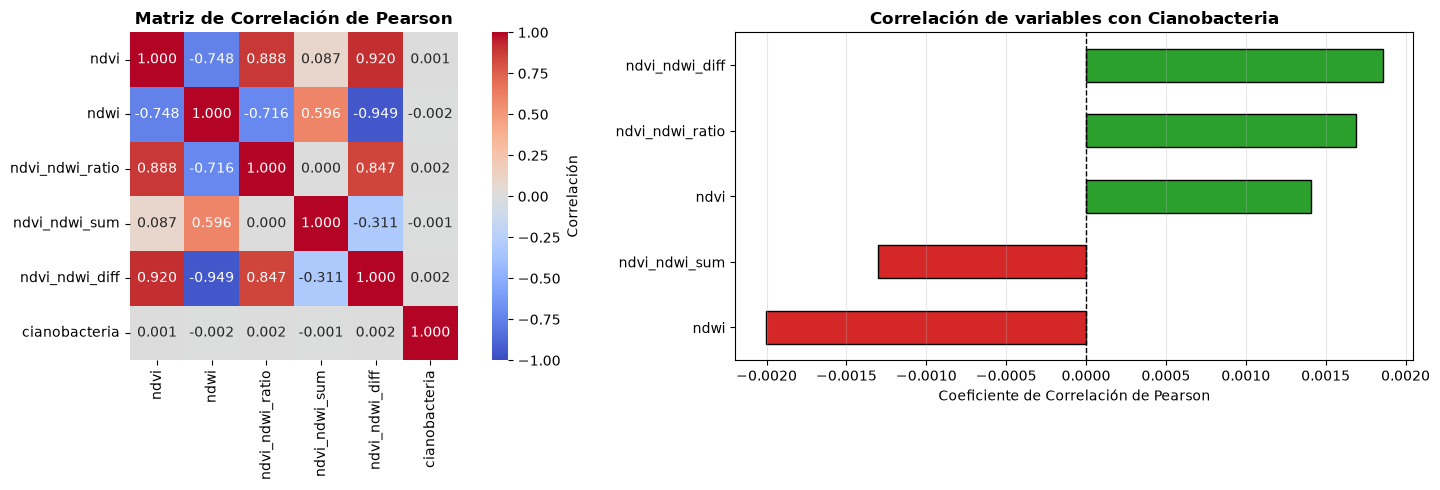


Variables con mayor correlación absoluta con cianobacteria:
------------------------------------------------------------


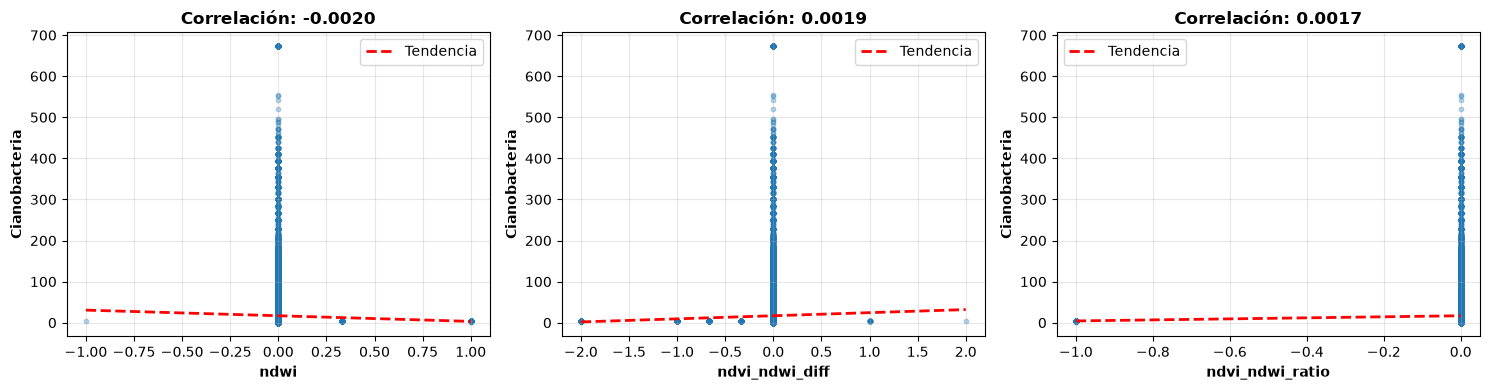

In [90]:
import seaborn as sns

# Heatmap de correlación
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap completo
sns.heatmap(matriz_corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, 
            square=True, ax=axes[0], cbar_kws={"label": "Correlación"}, vmin=-1, vmax=1)
axes[0].set_title("Matriz de Correlación de Pearson", fontweight="bold", fontsize=12)

# Gráfico de barras: correlación con cianobacteria
correlaciones_sorted = correlaciones.sort_values()
colores_bar = ["#d62728" if x < 0 else "#2ca02c" for x in correlaciones_sorted.values]
correlaciones_sorted.plot(kind="barh", ax=axes[1], color=colores_bar, edgecolor="black")
axes[1].set_title("Correlación de variables con Cianobacteria", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Coeficiente de Correlación de Pearson")
axes[1].axvline(x=0, color="black", linestyle="--", linewidth=1)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plots: variables con mayor correlación
print("\nVariables con mayor correlación absoluta con cianobacteria:")
print("-" * 60)
top_vars = correlaciones_sorted.abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, var in enumerate(top_vars):
    axes[idx].scatter(df_agua[var], df_agua["cianobacteria"], alpha=0.3, s=10, color="#1f77b4")
    axes[idx].set_xlabel(var, fontweight="bold")
    axes[idx].set_ylabel("Cianobacteria", fontweight="bold")
    axes[idx].set_title(f"Correlación: {correlaciones[var]:.4f}", fontweight="bold")
    axes[idx].grid(alpha=0.3)
    
    # Agregar línea de tendencia
    z = np.polyfit(df_agua[var], df_agua["cianobacteria"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_agua[var].min(), df_agua[var].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r--", linewidth=2, label="Tendencia")
    axes[idx].legend()

plt.tight_layout()
plt.show()

### 2.3 Análisis de distribución global, por lago y por fecha

Análisis comparativo de correlaciones para diferentes subconjuntos de datos.


ANÁLISIS DE CORRELACIÓN POR LAGO Y FECHA

Correlación por lago (NDVI y NDWI):
  Amatitlán: NDVI=0.0028, NDWI=-0.0028
  Atitlán: NDVI=0.0013, NDWI=-0.0019


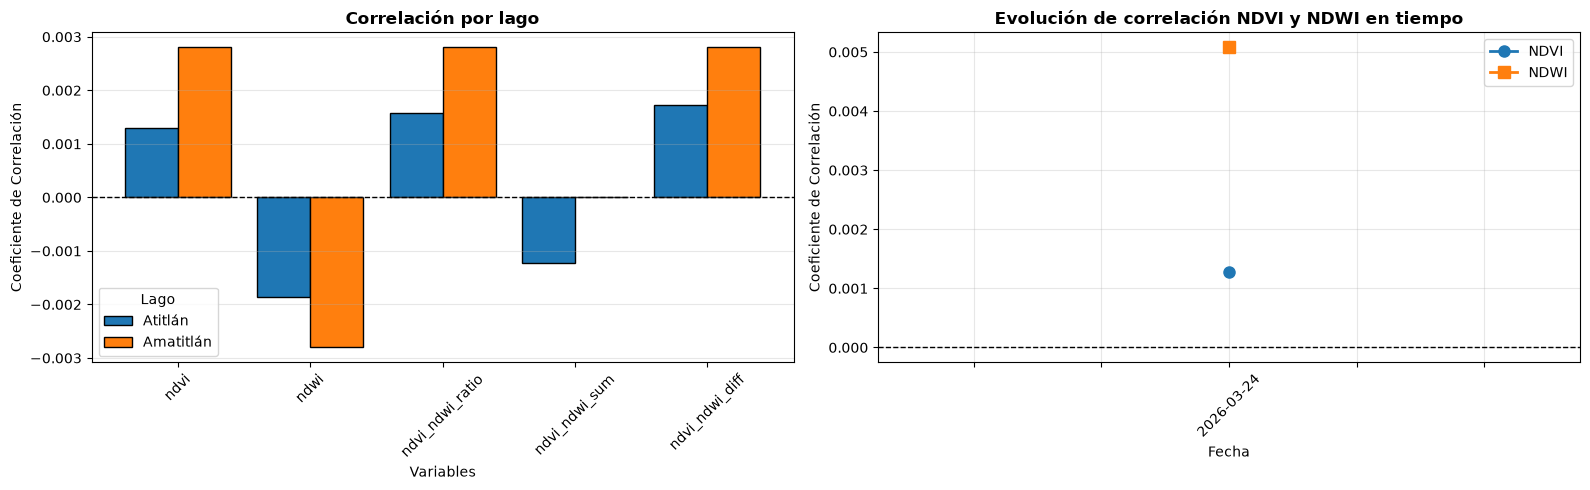

In [91]:
print("\n" + "=" * 80)
print("ANÁLISIS DE CORRELACIÓN POR LAGO Y FECHA")
print("=" * 80)

# Correlación por lago
print("\nCorrelación por lago (NDVI y NDWI):")
for lago in sorted(df_agua["lago"].unique()):
    df_lago = df_agua[df_agua["lago"] == lago]
    corr_lago = df_lago[variables_predictoras + [variable_respuesta]].corr()[variable_respuesta].drop(variable_respuesta)
    print(f"  {lago}: NDVI={corr_lago['ndvi']:.4f}, NDWI={corr_lago['ndwi']:.4f}")

# Visualización: correlaciones por lago y fecha
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Correlación por lago
correlaciones_atitlan = df_agua[df_agua["lago"] == "Atitlán"][variables_predictoras + [variable_respuesta]].corr()[variable_respuesta].drop(variable_respuesta)
correlaciones_amatitlan = df_agua[df_agua["lago"] == "Amatitlán"][variables_predictoras + [variable_respuesta]].corr()[variable_respuesta].drop(variable_respuesta)

comparativa_lagos = pd.DataFrame({
    "Atitlán": correlaciones_atitlan,
    "Amatitlán": correlaciones_amatitlan
})

comparativa_lagos.plot(kind="bar", ax=axes[0], width=0.8, edgecolor="black")
axes[0].set_title("Correlación por lago", fontweight="bold", fontsize=12)
axes[0].set_ylabel("Coeficiente de Correlación")
axes[0].set_xlabel("Variables")
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=1)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Lago")
axes[0].grid(axis="y", alpha=0.3)

# Correlación por fecha
fechas_principales = df_agua.groupby("fecha").size().nlargest(5).index
datos_por_fecha = {}
for fecha in fechas_principales:
    df_fecha = df_agua[df_agua["fecha"] == fecha]
    if len(df_fecha) > 10:
        corr_fecha = df_fecha[variables_predictoras + [variable_respuesta]].corr()[variable_respuesta].drop(variable_respuesta)
        datos_por_fecha[fecha.strftime("%Y-%m-%d")] = corr_fecha

comparativa_fechas = pd.DataFrame(datos_por_fecha)
comparativa_fechas.loc["ndvi"].plot(ax=axes[1], marker="o", linewidth=2, markersize=8, label="NDVI", color="#1f77b4")
comparativa_fechas.loc["ndwi"].plot(ax=axes[1], marker="s", linewidth=2, markersize=8, label="NDWI", color="#ff7f0e")
axes[1].set_title("Evolución de correlación NDVI y NDWI en tiempo", fontweight="bold", fontsize=12)
axes[1].set_ylabel("Coeficiente de Correlación")
axes[1].set_xlabel("Fecha")
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 2.4 Análisis de variabilidad temporal

Evaluar si existen diferencias significativas en las correlaciones a lo largo del tiempo.

In [92]:
print("\n" + "=" * 80)
print("ANÁLISIS DE VARIABILIDAD TEMPORAL")
print("=" * 80)

# Calcular correlaciones para todas las fechas
todas_correlaciones_por_fecha = {}
for fecha in sorted(df_agua["fecha"].unique()):
    df_fecha = df_agua[df_agua["fecha"] == fecha]
    if len(df_fecha) > 5:  # Mínimo 5 píxeles
        corr_fecha = df_fecha[variables_predictoras + [variable_respuesta]].corr()[variable_respuesta].drop(variable_respuesta)
        todas_correlaciones_por_fecha[fecha] = corr_fecha

# Tabla resumen
print("\nCorrelación de NDVI y NDWI a través del tiempo:")
print("-" * 80)
tabla_temporal = pd.DataFrame(todas_correlaciones_por_fecha).T[["ndvi", "ndwi"]]
tabla_temporal.index = tabla_temporal.index.strftime("%Y-%m-%d")
print(tabla_temporal)

# Estadísticas de variabilidad
print("\n\nEstadísticas de variabilidad (coeficiente de correlación):")
print("-" * 80)
for var in ["ndvi", "ndwi"]:
    valores = tabla_temporal[var].dropna()
    print(f"\n{var.upper()}:")
    print(f"  Mín: {valores.min():.4f}")
    print(f"  Máx: {valores.max():.4f}")
    print(f"  Promedio: {valores.mean():.4f}")
    print(f"  Desv. Est.: {valores.std():.4f}")
    print(f"  Rango: {valores.max() - valores.min():.4f}")

# Detectar cambios abruptos
print("\n\nCambios significativos en correlación (diferencia > 0.2):")
print("-" * 80)
for var in ["ndvi", "ndwi"]:
    valores = tabla_temporal[var].dropna().values
    for i in range(1, len(valores)):
        cambio = valores[i] - valores[i-1]
        if abs(cambio) > 0.2:
            fecha_anterior = tabla_temporal[var].index[i-1]
            fecha_actual = tabla_temporal[var].index[i]
            print(f"  {var}: {fecha_anterior} → {fecha_actual}: cambio de {cambio:+.4f}")


ANÁLISIS DE VARIABILIDAD TEMPORAL

Correlación de NDVI y NDWI a través del tiempo:
--------------------------------------------------------------------------------
                ndvi      ndwi
2025-01-18       NaN       NaN
2025-01-28       NaN       NaN
2025-04-13       NaN       NaN
2025-04-15       NaN       NaN
2025-04-28       NaN       NaN
2025-05-13       NaN       NaN
2025-07-17       NaN       NaN
2025-11-21  0.000947 -0.001241
2025-11-24       NaN       NaN
2025-12-29  0.000983 -0.001366
2026-01-08       NaN       NaN
2026-02-02  0.064603 -0.064603
2026-02-07       NaN       NaN
2026-02-12       NaN       NaN
2026-03-24  0.001277  0.005078
2026-03-29       NaN       NaN
2026-04-13       NaN       NaN
2026-04-28       NaN       NaN
2026-06-19  0.013767 -0.013767
2026-07-22       NaN       NaN


Estadísticas de variabilidad (coeficiente de correlación):
--------------------------------------------------------------------------------

NDVI:
  Mín: 0.0009
  Máx: 0.0646
  Prome

### 2.5 Identificación de variables sin utilidad predictora

Detectar variables que no tengan correlación significativa con la variable respuesta (posibles candidatos para eliminación).

In [94]:
from scipy import stats

print("\n" + "=" * 80)
print("ANÁLISIS DE UTILIDAD PREDICTORA DE VARIABLES")
print("=" * 80)

# Calcular correlaciones y p-valores
print("\nPrueba de correlación (Pearson) - Variables vs Cianobacteria:")
print("-" * 80)
print(f"{'Variable':<30} {'Correlación':>15} {'P-valor':>15} {'Significancia':>15}")
print("-" * 80)

variables_no_utiles = []
variables_utiles = []

for var in variables_predictoras:
    corr, p_valor = stats.pearsonr(df_agua[var], df_agua["cianobacteria"])
    significancia = "***" if p_valor < 0.001 else "**" if p_valor < 0.01 else "*" if p_valor < 0.05 else "NS"
    
    print(f"{var:<30} {corr:>15.4f} {p_valor:>15.4e} {significancia:>15}")
    
    # Clasificar: "no útil" si correlación baja Y no significativa
    if abs(corr) < 0.3 and p_valor > 0.05:
        variables_no_utiles.append(var)
    else:
        variables_utiles.append(var)

print("\n" + "=" * 80)
print("CLASIFICACIÓN DE VARIABLES")
print("=" * 80)

print("\n✓ VARIABLES ÚTILES (correlación > 0.3 O p-valor < 0.05):")
for var in variables_utiles:
    corr = correlaciones[var]
    print(f"  - {var}: r={corr:.4f}")

if variables_no_utiles:
    print("\n✗ VARIABLES SIN UTILIDAD PREDICTORA (correlación < 0.3 Y p-valor > 0.05):")
    for var in variables_no_utiles:
        corr = correlaciones[var]
        print(f"  - {var}: r={corr:.4f} (Recomendación: considerar eliminación)")
else:
    print("\n✓ Todas las variables tienen utilidad predictora")

# Resumen de calidad del dataset
print("\n" + "=" * 80)
print("RESUMEN DEL EJERCICIO 2")
print("=" * 80)
print(f"\nVariables analizadas: {len(variables_predictoras)}")
print(f"Variables útiles: {len(variables_utiles)}")
print(f"Variables no útiles: {len(variables_no_utiles)}")
print(f"\nCorrelación promedio con cianobacteria: {abs(correlaciones).mean():.4f}")
print(f"Correlación máxima: {correlaciones.abs().max():.4f}")
print(f"Correlación mínima: {correlaciones.abs().min():.4f}")



ANÁLISIS DE UTILIDAD PREDICTORA DE VARIABLES

Prueba de correlación (Pearson) - Variables vs Cianobacteria:
--------------------------------------------------------------------------------
Variable                           Correlación         P-valor   Significancia
--------------------------------------------------------------------------------
ndvi                                    0.0014      4.2255e-02               *
ndwi                                   -0.0020      3.8714e-03              **
ndvi_ndwi_ratio                         0.0017      1.4915e-02               *
ndvi_ndwi_sum                          -0.0013      6.0295e-02              NS
ndvi_ndwi_diff                          0.0019      7.4110e-03              **

CLASIFICACIÓN DE VARIABLES

✓ VARIABLES ÚTILES (correlación > 0.3 O p-valor < 0.05):
  - ndvi: r=0.0014
  - ndwi: r=-0.0020
  - ndvi_ndwi_ratio: r=0.0017
  - ndvi_ndwi_diff: r=0.0019

✗ VARIABLES SIN UTILIDAD PREDICTORA (correlación < 0.3 Y p-valor > 0.0

## 7. Ejercicio 3: Construcción de la Variable Respuesta

### 3.1 Categorización de la variable respuesta

Crear una variable de clasificación basada en el índice de cianobacteria (no agua, presencia, floración).

In [95]:
print("=" * 80)
print("CONSTRUCCIÓN DE VARIABLE RESPUESTA - CATEGORIZACIÓN")
print("=" * 80)

# Crear variable categórica a partir del índice de cianobacteria
# Categorías: 0=No agua, 1=Agua sin floración, 2=Floración, 3=Alta cianobacteria

df_ml["clase_cianobacteria"] = 0  # Default: no agua

# Floración superficial (valor = -1)
df_ml.loc[df_ml["cianobacteria"] == -1, "clase_cianobacteria"] = 2

# Agua sin presencia significativa (0 < valor < 10)
df_ml.loc[(df_ml["cianobacteria"] > 0) & (df_ml["cianobacteria"] < 10), "clase_cianobacteria"] = 1

# Alta cianobacteria (valor >= 10)
df_ml.loc[df_ml["cianobacteria"] >= 10, "clase_cianobacteria"] = 3

# Crear etiquetas descriptivas
etiquetas_clase = {0: "No agua", 1: "Agua limpia", 2: "Floración", 3: "Alta cianobacteria"}
df_ml["clase_nombre"] = df_ml["clase_cianobacteria"].map(etiquetas_clase)

print("\nDistribución de clases:")
print("-" * 60)
distribucion = df_ml["clase_nombre"].value_counts()
for clase, count in distribucion.items():
    pct = (count / len(df_ml)) * 100
    print(f"  {clase:<20}: {count:>12,} píxeles ({pct:>6.2f}%)")

print(f"\n  TOTAL             : {len(df_ml):>12,} píxeles (100.00%)")

# Estadísticas por clase
print("\n" + "=" * 80)
print("ESTADÍSTICAS DE CIANOBACTERIA POR CLASE")
print("=" * 80)

for clase_num in sorted(df_ml["clase_cianobacteria"].unique()):
    clase_nombre = etiquetas_clase[clase_num]
    df_clase = df_ml[df_ml["clase_cianobacteria"] == clase_num]
    
    if len(df_clase) > 0:
        print(f"\n{clase_nombre}:")
        print(f"  Cantidad: {len(df_clase):,}")
        print(f"  Cianobacteria - Min: {df_clase['cianobacteria'].min():.2f}, " +
              f"Max: {df_clase['cianobacteria'].max():.2f}, " +
              f"Media: {df_clase['cianobacteria'].mean():.2f}")

CONSTRUCCIÓN DE VARIABLE RESPUESTA - CATEGORIZACIÓN

Distribución de clases:
------------------------------------------------------------
  No agua             :   14,431,732 píxeles ( 87.39%)
  Agua limpia         :    1,856,366 píxeles ( 11.24%)
  Alta cianobacteria  :      224,765 píxeles (  1.36%)
  Floración           :          722 píxeles (  0.00%)

  TOTAL             :   16,513,585 píxeles (100.00%)

ESTADÍSTICAS DE CIANOBACTERIA POR CLASE

No agua:
  Cantidad: 14,431,732
  Cianobacteria - Min: -1017.93, Max: 0.00, Media: -5.12

Agua limpia:
  Cantidad: 1,856,366
  Cianobacteria - Min: 0.00, Max: 10.00, Media: 3.90

Floración:
  Cantidad: 722
  Cianobacteria - Min: -1.00, Max: -1.00, Media: -1.00

Alta cianobacteria:
  Cantidad: 224,765
  Cianobacteria - Min: 10.00, Max: 673.21, Media: 123.83


### 3.2 Análisis de balance de clases

Visualizar la distribución de clases y detectar desbalances.


ANÁLISIS DE BALANCE DE CLASES


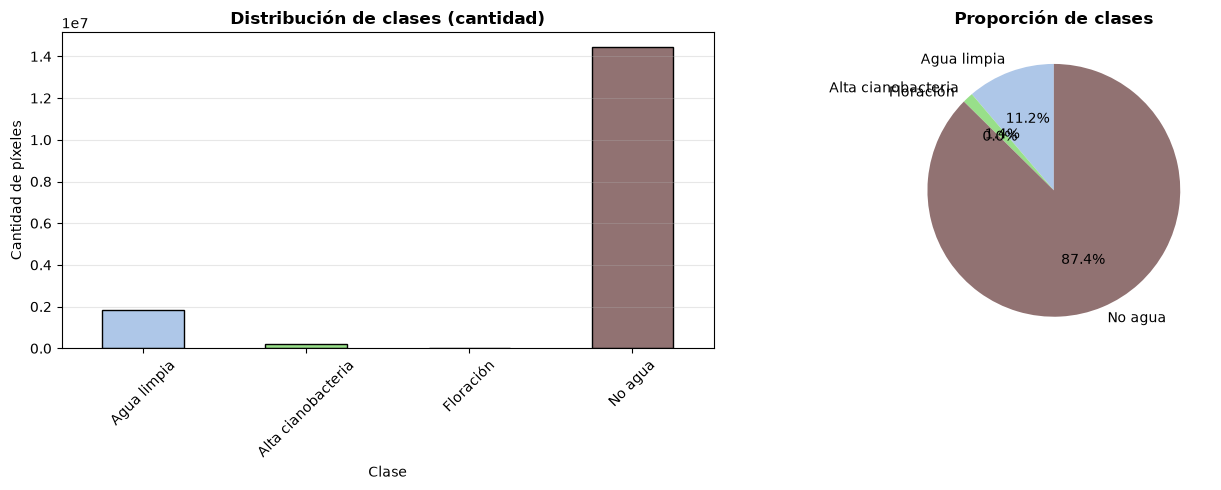


Indicador de desbalance:
------------------------------------------------------------
  Agua limpia         :    1,856,366 (11.24%) - Ratio:   7.77x
  Alta cianobacteria  :      224,765 ( 1.36%) - Ratio:  64.21x
  Floración           :          722 ( 0.00%) - Ratio: 19988.55x
  No agua             :   14,431,732 (87.39%) - Ratio:   1.00x

RECOMENDACIÓN
⚠ Existe DESBALANCE SIGNIFICATIVO entre clases
  → Se recomienda usar técnicas de balanceo (SMOTE, pesos, stratified split)


In [97]:
print("\n" + "=" * 80)
print("ANÁLISIS DE BALANCE DE CLASES")
print("=" * 80)

distribucion = df_ml["clase_nombre"].value_counts().sort_index()
pesos = distribucion / distribucion.sum()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cantidad de píxeles por clase
colores = ["#aec7e8", "#98df8a", "#ffbb78", "#917272"]
distribucion.plot(kind="bar", ax=axes[0], color=colores, edgecolor="black")
axes[0].set_title("Distribución de clases (cantidad)", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad de píxeles")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

# Gráfico 2: Proporción de clases
pesos.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", colors=colores, 
           labels=distribucion.index, startangle=90)
axes[1].set_title("Proporción de clases", fontweight="bold", fontsize=12)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Análisis de desbalance
print("\nIndicador de desbalance:")
print("-" * 60)
clase_mayoritaria = distribucion.max()
for clase, count in distribucion.items():
    ratio = clase_mayoritaria / count if count > 0 else float('inf')
    print(f"  {clase:<20}: {count:>12,} ({pesos[clase]*100:>5.2f}%) - Ratio: {ratio:>6.2f}x")

# Recomendación
print("\n" + "=" * 80)
print("RECOMENDACIÓN")
print("=" * 80)
if clase_mayoritaria / distribucion.min() > 3:
    print("⚠ Existe DESBALANCE SIGNIFICATIVO entre clases")
    print("  → Se recomienda usar técnicas de balanceo (SMOTE, pesos, stratified split)")
else:
    print("✓ Las clases están relativamente balanceadas")

### 3.3 División del dataset: Entrenamiento, Validación y Prueba

Crear conjuntos de datos estratificados (80% entrenamiento, 10% validación, 10% prueba).

In [98]:
from sklearn.model_selection import train_test_split

print("\n" + "=" * 80)
print("DIVISIÓN DEL DATASET: TRAIN / VALIDATION / TEST")
print("=" * 80)

# Variables predictoras y variable respuesta
variables_predictoras_final = ["ndvi", "ndwi", "ndvi_ndwi_ratio", "ndvi_ndwi_sum", "ndvi_ndwi_diff"]
variable_respuesta_clase = "clase_cianobacteria"

X = df_ml[variables_predictoras_final].copy()
y = df_ml[variable_respuesta_clase].copy()

print(f"\nDataset original: {len(X)} observaciones")

# Primera división: 80% train+val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.1, 
    random_state=42, 
    stratify=y
)

# Segunda división: 80% train (de train_val), 20% val (de train_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.111,  # 10% de 90% = 10% del total
    random_state=42, 
    stratify=y_train_val
)

# Resumen
print("\nDistribución final:")
print("-" * 60)
print(f"  Entrenamiento: {len(X_train):>12,} píxeles ({len(X_train)/len(X)*100:>6.2f}%)")
print(f"  Validación   : {len(X_val):>12,} píxeles ({len(X_val)/len(X)*100:>6.2f}%)")
print(f"  Prueba       : {len(X_test):>12,} píxeles ({len(X_test)/len(X)*100:>6.2f}%)")
print(f"  TOTAL        : {len(X):>12,} píxeles (100.00%)")

# Verificar balance en cada conjunto
print("\n" + "=" * 80)
print("DISTRIBUCIÓN DE CLASES POR CONJUNTO")
print("=" * 80)

for nombre, y_conjunto in [("Entrenamiento", y_train), ("Validación", y_val), ("Prueba", y_test)]:
    print(f"\n{nombre}:")
    distribucion_conjunto = y_conjunto.value_counts().sort_index()
    for clase_num in sorted(y_conjunto.unique()):
        clase_nombre = etiquetas_clase[clase_num]
        count = distribucion_conjunto[clase_num]
        pct = (count / len(y_conjunto)) * 100
        print(f"  {clase_nombre:<20}: {count:>10,} ({pct:>5.2f}%)")


DIVISIÓN DEL DATASET: TRAIN / VALIDATION / TEST

Dataset original: 16513585 observaciones

Distribución final:
------------------------------------------------------------
  Entrenamiento:   13,212,518 píxeles ( 80.01%)
  Validación   :    1,649,708 píxeles (  9.99%)
  Prueba       :    1,651,359 píxeles ( 10.00%)
  TOTAL        :   16,513,585 píxeles (100.00%)

DISTRIBUCIÓN DE CLASES POR CONJUNTO

Entrenamiento:
  No agua             : 11,546,827 (87.39%)
  Agua limpia         :  1,485,278 (11.24%)
  Floración           :        578 ( 0.00%)
  Alta cianobacteria  :    179,835 ( 1.36%)

Validación:
  No agua             :  1,441,731 (87.39%)
  Agua limpia         :    185,451 (11.24%)
  Floración           :         72 ( 0.00%)
  Alta cianobacteria  :     22,454 ( 1.36%)

Prueba:
  No agua             :  1,443,174 (87.39%)
  Agua limpia         :    185,637 (11.24%)
  Floración           :         72 ( 0.00%)
  Alta cianobacteria  :     22,476 ( 1.36%)


### 3.4 Resumen y preparación final del dataset

Análisis final de la calidad del dataset para Machine Learning.


RESUMEN FINAL - DATASET PREPARADO PARA MACHINE LEARNING

1. INFORMACIÓN DEL DATASET
------------------------------------------------------------
  Total de observaciones: 16,513,585
  Total de características: 5
  Características: ndvi, ndwi, ndvi_ndwi_ratio, ndvi_ndwi_sum, ndvi_ndwi_diff
  Variable respuesta: clase_cianobacteria (4 clases)
  Rango de datos: 22 fechas
  Cobertura geográfica: Atitlán + Amatitlán

2. CALIDAD DE DATOS
------------------------------------------------------------
  Valores faltantes: 0
  Duplicados: 0
  Rango de NDVI: [-1.0000, 1.0000]
  Rango de NDWI: [-1.0000, 1.0000]

3. DIVISIÓN DEL DATASET
------------------------------------------------------------
  Entrenamiento: 13,212,518 ( 80.0%)
  Validación   :  1,649,708 ( 10.0%)
  Prueba       :  1,651,359 ( 10.0%)

4. BALANCE DE CLASES (GLOBAL)
------------------------------------------------------------
  No agua             : 14,431,732 ( 87.4%)
  Agua limpia         :  1,856,366 ( 11.2%)
  Floración     

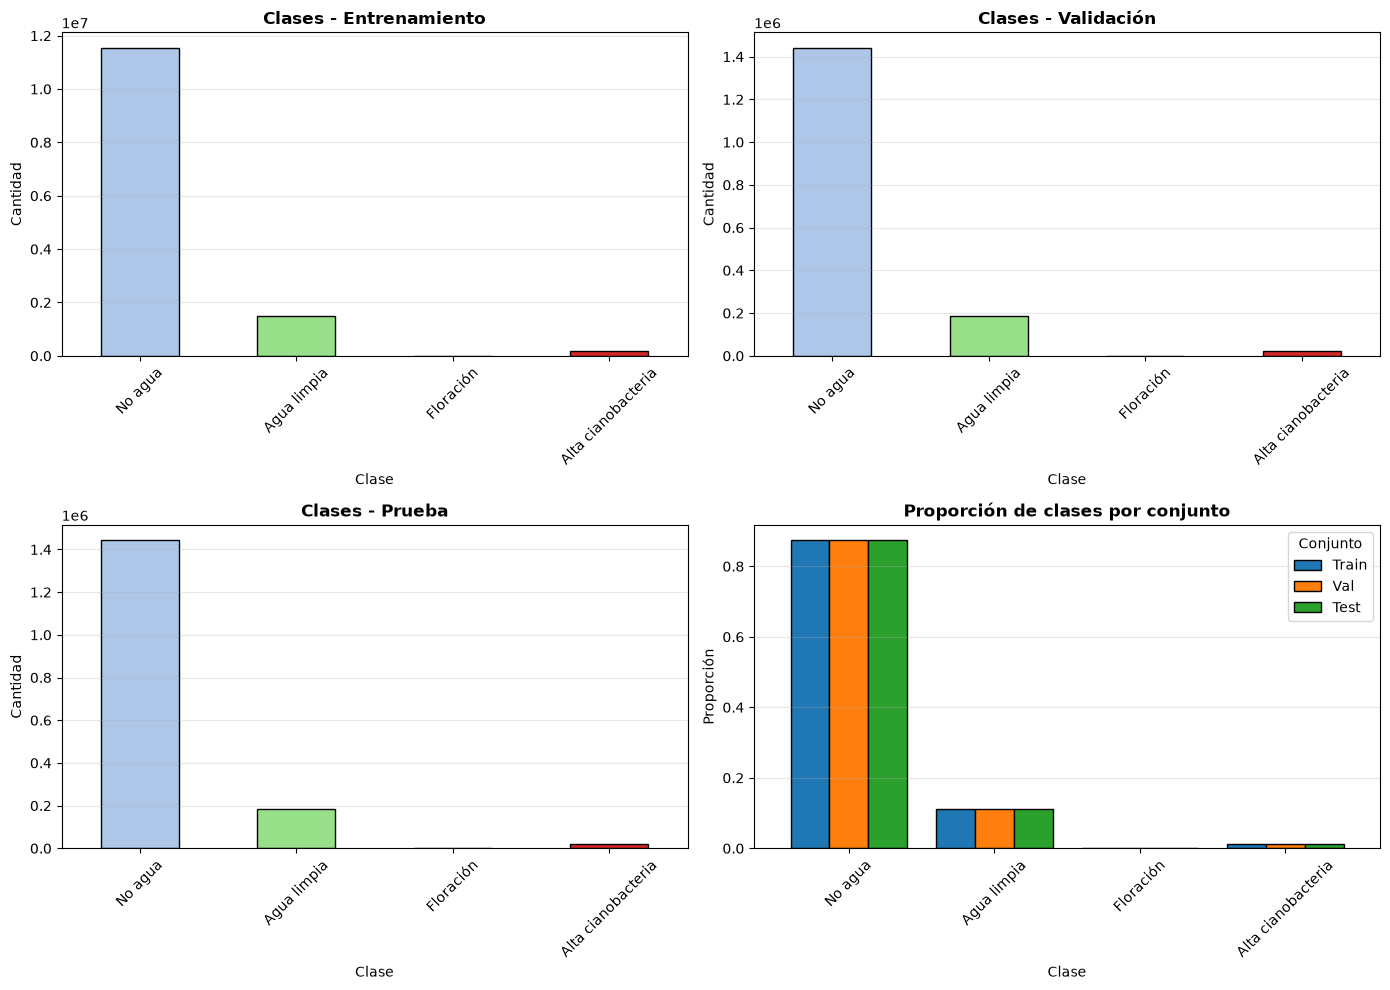

In [100]:
print("\n" + "=" * 80)
print("RESUMEN FINAL - DATASET PREPARADO PARA MACHINE LEARNING")
print("=" * 80)

print("\n1. INFORMACIÓN DEL DATASET")
print("-" * 60)
print(f"  Total de observaciones: {len(df_ml):,}")
print(f"  Total de características: {len(variables_predictoras_final)}")
print(f"  Características: {', '.join(variables_predictoras_final)}")
print(f"  Variable respuesta: clase_cianobacteria (4 clases)")
print(f"  Rango de datos: {len(fechas_atitlan) + len(fechas_amatitlan)} fechas")
print(f"  Cobertura geográfica: Atitlán + Amatitlán")

print("\n2. CALIDAD DE DATOS")
print("-" * 60)
print(f"  Valores faltantes: {df_ml[variables_predictoras_final].isna().sum().sum()}")
print(f"  Duplicados: {df_ml.duplicated().sum()}")
print(f"  Rango de NDVI: [{df_ml['ndvi'].min():.4f}, {df_ml['ndvi'].max():.4f}]")
print(f"  Rango de NDWI: [{df_ml['ndwi'].min():.4f}, {df_ml['ndwi'].max():.4f}]")

print("\n3. DIVISIÓN DEL DATASET")
print("-" * 60)
print(f"  Entrenamiento: {len(X_train):>10,} ({len(X_train)/len(X)*100:>5.1f}%)")
print(f"  Validación   : {len(X_val):>10,} ({len(X_val)/len(X)*100:>5.1f}%)")
print(f"  Prueba       : {len(X_test):>10,} ({len(X_test)/len(X)*100:>5.1f}%)")

print("\n4. BALANCE DE CLASES (GLOBAL)")
print("-" * 60)
dist_global = y.value_counts().sort_index()
for clase_num in sorted(y.unique()):
    clase_nombre = etiquetas_clase[clase_num]
    count = dist_global[clase_num]
    pct = (count / len(y)) * 100
    print(f"  {clase_nombre:<20}: {count:>10,} ({pct:>5.1f}%)")

# Visualización final
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de clases por conjunto
conjuntos = ["Entrenamiento", "Validación", "Prueba"]
for idx, (nombre, y_c) in enumerate([(conjuntos[0], y_train), (conjuntos[1], y_val), (conjuntos[2], y_test)]):
    if idx < 3:
        ax = axes[idx // 2, idx % 2]
        dist_c = y_c.value_counts().sort_index()
        nombres_clases = [etiquetas_clase[i] for i in dist_c.index]
        colores = ["#aec7e8", "#98df8a", "#ffbb78", "#d62728"]
        dist_c.plot(kind="bar", ax=ax, color=colores[:len(dist_c)], edgecolor="black")
        ax.set_title(f"Clases - {nombre}", fontweight="bold")
        ax.set_xlabel("Clase")
        ax.set_ylabel("Cantidad")
        ax.set_xticklabels(nombres_clases, rotation=45)
        ax.grid(axis="y", alpha=0.3)

# 4. Comparativa de proporciones
ax = axes[1, 1]
proporciones = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Val": y_val.value_counts(normalize=True).sort_index(),
    "Test": y_test.value_counts(normalize=True).sort_index()
})
proporciones.index = [etiquetas_clase[i] for i in proporciones.index]
proporciones.plot(kind="bar", ax=ax, width=0.8, edgecolor="black")
ax.set_title("Proporción de clases por conjunto", fontweight="bold")
ax.set_ylabel("Proporción")
ax.set_xlabel("Clase")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Conjunto")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



### Inciso 3.5: Normalización

In [101]:

from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=variables_predictoras_final)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=variables_predictoras_final)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=variables_predictoras_final)

# Inciso 3.6: Exportación
import os
os.makedirs("datos_ml", exist_ok=True)

X_train.to_csv("datos_ml/X_train.csv", index=False)
X_val.to_csv("datos_ml/X_val.csv", index=False)
X_test.to_csv("datos_ml/X_test.csv", index=False)
y_train.to_csv("datos_ml/y_train.csv", index=False)
y_val.to_csv("datos_ml/y_val.csv", index=False)
y_test.to_csv("datos_ml/y_test.csv", index=False)

with open("datos_ml/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✓ Datos guardados en carpeta datos_ml/")

✓ Datos guardados en carpeta datos_ml/
